In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/CaptureSensor_BP_C_0_Color"
mask_path    = "/content/drive/MyDrive/masks"

In [4]:
#Check if Datset is mounted properly
import os

dataset_path = "/content/drive/MyDrive/CaptureSensor_BP_C_0_Color"
image_files = sorted(os.listdir(dataset_path))

print(len(image_files))
print(image_files[:5])

120
['0000000.png', '0000001.png', '0000002.png', '0000003.png', '0000004.png']


In [5]:
!pip install transformers

In [7]:
import os
import torch
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

dataset_path = "/content/drive/MyDrive/CaptureSensor_BP_C_0_Color"
mask_path = "/content/drive/MyDrive/masks"
os.makedirs(mask_path, exist_ok=True)

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model.eval()

files = sorted(os.listdir(dataset_path))

for img_name in files:
    img_path = os.path.join(dataset_path, img_name)
    image = Image.open(img_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1)[0].cpu().numpy()

    Image.fromarray(pred.astype("uint8")).save(os.path.join(mask_path, img_name))

print("✅ Masks generated!")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

✅ Masks generated!


In [8]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

image_dir = "/content/drive/MyDrive/CaptureSensor_BP_C_0_Color"
mask_dir  = "/content/drive/MyDrive/masks"
save_dir  = "/content/drive/MyDrive/segformer_model"

os.makedirs(save_dir, exist_ok=True)

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")

class SegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, processor):
        self.images = sorted(os.listdir(image_dir))
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.processor = processor

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        image = Image.open(os.path.join(self.image_dir, img_name)).convert("RGB")
        mask  = Image.open(os.path.join(self.mask_dir, img_name))

        inputs = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(),
            "labels": inputs["labels"].squeeze()
        }

dataset = SegDataset(image_dir, mask_dir, processor)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(3):
    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

print("✅ Training + Processor saved successfully!")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Epoch 1, Loss: 0.8652455806732178
Epoch 2, Loss: 0.894788384437561
Epoch 3, Loss: 0.2911224961280823


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training + Processor saved successfully!


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

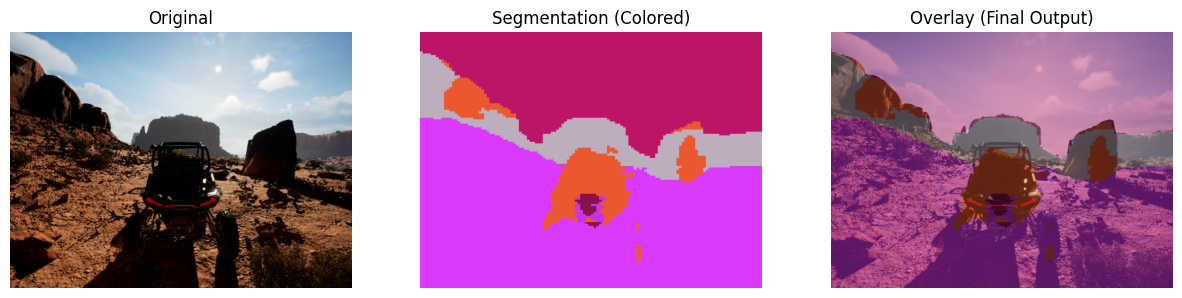

In [9]:
import os
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("/content/drive/MyDrive/segformer_model")

model.eval()

dataset_path = "/content/drive/MyDrive/CaptureSensor_BP_C_0_Color"
files = sorted(os.listdir(dataset_path))

img_path = os.path.join(dataset_path, files[10])
image = Image.open(img_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

pred = torch.argmax(outputs.logits, dim=1)[0].cpu().numpy()

pred_resized = cv2.resize(
    pred,
    (image.width, image.height),
    interpolation=cv2.INTER_NEAREST
)

num_classes = 150
np.random.seed(42)

colors = np.random.randint(0, 255, (num_classes, 3))

color_mask = np.zeros((pred_resized.shape[0], pred_resized.shape[1], 3), dtype=np.uint8)

for label in range(num_classes):
    color_mask[pred_resized == label] = colors[label]

overlay = (0.6 * np.array(image) + 0.4 * color_mask).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(color_mask)
plt.title("Segmentation (Colored)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay (Final Output)")
plt.axis("off")

plt.show()

Saving horizontal-shot-mountain-landscape-namib-desert-namibia-blue-sky_181624-18310.avif to horizontal-shot-mountain-landscape-namib-desert-namibia-blue-sky_181624-18310.avif


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

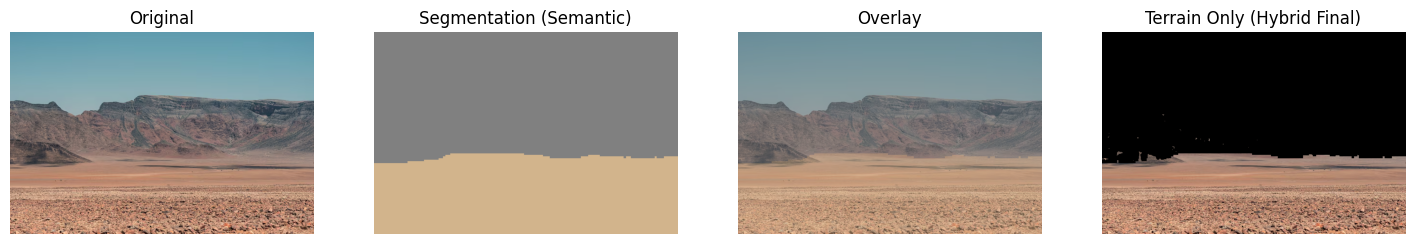

In [10]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
image = Image.open(img_path).convert("RGB")

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("/content/drive/MyDrive/segformer_model")

model.eval()

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

pred = torch.argmax(outputs.logits, dim=1)[0].cpu().numpy()

pred_resized = cv2.resize(
    pred,
    (image.width, image.height),
    interpolation=cv2.INTER_NEAREST
)

color_map = {
    3: [0, 0, 255],
    13: [210, 180, 140],
    14: [222, 184, 135],
    12: [255, 0, 0],
}

default_color = [128, 128, 128]

color_mask = np.zeros((pred_resized.shape[0], pred_resized.shape[1], 3), dtype=np.uint8)

for label in np.unique(pred_resized):
    color = color_map.get(label, default_color)
    color_mask[pred_resized == label] = color

overlay = (0.6 * np.array(image) + 0.4 * color_mask).astype(np.uint8)


terrain_classes = [13, 14]
vehicle_class = 12

terrain_mask_seg = np.isin(pred_resized, terrain_classes)
terrain_mask_seg[pred_resized == vehicle_class] = False

img_np = np.array(image)
hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

lower = np.array([10, 50, 50])
upper = np.array([30, 255, 255])

terrain_mask_color = cv2.inRange(hsv, lower, upper)
terrain_mask_color = terrain_mask_color > 0

terrain_mask = terrain_mask_seg | terrain_mask_color

kernel = np.ones((5,5), np.uint8)
terrain_mask = cv2.morphologyEx(terrain_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

terrain_only = img_np.copy()
terrain_only[terrain_mask == 0] = 0

plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(color_mask)
plt.title("Segmentation (Semantic)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(terrain_only)
plt.title("Terrain Only (Hybrid Final)")
plt.axis("off")

plt.show()